In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-5-mini", 
    api_key=openai_api_key
)

ollama_llm = ChatOllama(
    model="llama3.1:latest",
    temperature=0
)

# google_llm.invoke("what is 2+2").content

## Parallelization

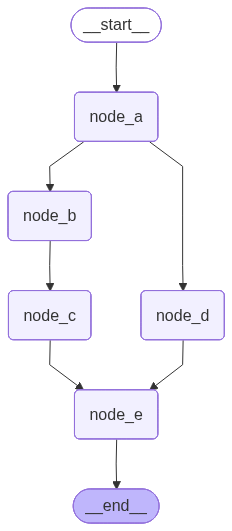

In [55]:
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import TypedDict, Annotated, List
from IPython.display import display, Image
import operator

# class State(TypedDict):
#     msg: Annotated[list, operator.add]

class State(MessagesState):
    pass

builder = StateGraph(State)



def node_a(state: State):
    return {'messages': 'I am A'}

def node_b(state: State):
    return {'messages': 'I am B'}

def node_c(state: State):
    return {'messages': 'I am C'}

def node_d(state: State):
    return {'messages': 'I am D'}

def node_e(state: State):
    return {'messages': 'I am E'}


builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)
builder.add_node("node_e", node_e)


builder.add_edge(START, 'node_a')
builder.add_edge('node_a', 'node_b')
builder.add_edge('node_a', 'node_d')
builder.add_edge('node_b', 'node_c')
builder.add_edge('node_c', 'node_e')
builder.add_edge('node_d', 'node_e')
builder.add_edge('node_e', END)

graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))

In [56]:
res = graph.invoke({'messages': 'I am Praveen'})

for msg in res.get('messages'):
    msg.pretty_print()

================================ Human Message =================================

I am Praveen
================================ Human Message =================================

I am A
================================ Human Message =================================

I am B
================================ Human Message =================================

I am D
================================ Human Message =================================

I am C
================================ Human Message =================================

I am E
================================ Human Message =================================

I am E


### Note:
- Node E will run only after all nodes above are done executing
- Node E is running twice while merging because physical nodes above differs in numbers. (not based on above node execution time)

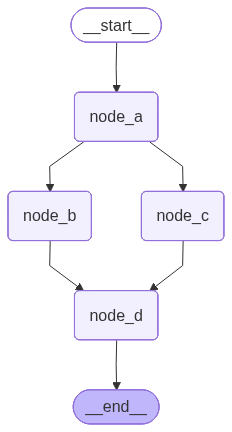

In [60]:
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import TypedDict, Annotated, List
from IPython.display import display, Image
import operator
import time

# class State(TypedDict):
#     msg: Annotated[list, operator.add]

class State(MessagesState):
    pass

builder = StateGraph(State)



def node_a(state: State):
    return {'messages': 'I am A'}

def node_b(state: State):
    return {'messages': 'I am B'}

def node_c(state: State):
    time.sleep(5)
    return {'messages': 'I am C'}

def node_d(state: State):
    return {'messages': 'I am D'}


builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)


builder.add_edge(START, 'node_a')
builder.add_edge('node_a', 'node_b')
builder.add_edge('node_a', 'node_c')
builder.add_edge('node_b', 'node_d')
builder.add_edge('node_c', 'node_d')
builder.add_edge('node_d', END)

graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
res = graph.invoke({'messages': 'I am Praveen'})

for msg in res.get('messages'):
    msg.pretty_print()

================================ Human Message =================================

I am Praveen
================================ Human Message =================================

I am A
================================ Human Message =================================

I am B
================================ Human Message =================================

I am C
================================ Human Message =================================

I am D


## Custom Reducer to control order of execution

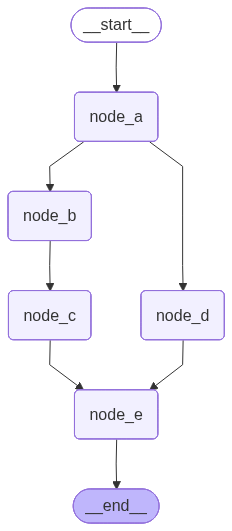

In [ ]:
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import TypedDict, Annotated, List
from IPython.display import display, Image
import operator

def custom_reducer(left, right):

    if not isinstance(left, list):
        left = [left]

    if not isinstance(right, list):
        right = [right]

    print(f"Left is {left}")   
    print(f"Right is {right}\n\n")

    return sorted(left + right, reverse=False) # this sorts based on text output, in actual production code, sort based on type like this -  sorted(left + right, key=lambda x: x.created_at, reverse = True)

class State(TypedDict):
    messages: Annotated[list, custom_reducer]

# class State(MessagesState):
#     pass

builder = StateGraph(State)



def node_a(state: State):
    return {'messages': 'I am A'}

def node_b(state: State):
    return {'messages': 'I am B'}

def node_c(state: State):
    return {'messages': 'I am C'}

def node_d(state: State):
    return {'messages': 'I am D'}

def node_e(state: State):
    return {'messages': 'I am E'}


builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)
builder.add_node("node_e", node_e)


builder.add_edge(START, 'node_a')
builder.add_edge('node_a', 'node_b')
builder.add_edge('node_a', 'node_d')
builder.add_edge('node_b', 'node_c')
builder.add_edge('node_c', 'node_e')
builder.add_edge('node_d', 'node_e')
builder.add_edge('node_e', END)

graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))

In [54]:
res = graph.invoke({'messages': 'I am Praveen'})

for msg in res.get('messages'):
    print(msg)

Left is []
Right is ['I am Praveen']


Left is ['I am Praveen']
Right is ['I am A']


Left is ['I am A', 'I am Praveen']
Right is ['I am B']


Left is ['I am A', 'I am B', 'I am Praveen']
Right is ['I am D']


Left is ['I am A', 'I am B', 'I am D', 'I am Praveen']
Right is ['I am C']


Left is ['I am A', 'I am B', 'I am C', 'I am D', 'I am Praveen']
Right is ['I am E']


Left is ['I am A', 'I am B', 'I am C', 'I am D', 'I am E', 'I am Praveen']
Right is ['I am E']


I am A
I am B
I am C
I am D
I am E
I am E
I am Praveen


# Do Talily & Wikipedia branching for demo